# MRI1 — Lecture 3: Dynamics of $M$ in $B_0$ and Resonant Excitation

> **Note on lecture content.** The uploaded PDF for "Lecture 3" actually contains material from sections **5.5 (time evolution of $M_\perp$ in $B_0$)** and **6 (excitation of $M$)** of the MRI1 script — i.e. the dynamics of magnetization in the static field followed by the introduction of the $B_1^+$ field, the rotating reference frame (RRF), and the canonical 90°/180° pulses. The notebook below follows that content.

## Learning objectives

By the end of this notebook you will be able to:

- **Solve the Bloch equation** $\dot{\boldsymbol M} = \gamma \boldsymbol B \times \boldsymbol M$ numerically and check it against the analytic solution for a static $\boldsymbol B_0$.
- **Explain why $|\boldsymbol M(t)|$ is conserved** both algebraically ($\cos^2+\sin^2=1$) and geometrically ($\dot{\boldsymbol M}\perp\boldsymbol M$).
- **Transform between the lab frame and the rotating reference frame (RRF)** and see why $\boldsymbol B_0$ "disappears" at resonance.
- **Design a 90° excitation, 180° inversion, and 180° refocusing pulse** by picking $t_{\mathrm{HF}}$ for a given $B_1^+$.
- **Choose the rotation axis** in the RRF via the pulse phase $\theta_{B_1}$.
- **Recognize the lab-frame excitation trajectory** — the spiral of a slow $\omega_1$ tilt riding on a fast $\omega_0$ precession.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

rng = np.random.default_rng(seed=42)

plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 1.6

# Physical constants used throughout
GAMMA = 2 * np.pi * 42.577478e6   # proton gyromagnetic ratio [rad/s/T]
B0     = 1.5                      # main field [T] — clinical 1.5 T scanner
W0     = GAMMA * B0               # Larmor angular frequency [rad/s]

print(f"gamma     = {GAMMA:.3e} rad/s/T")
print(f"B0        = {B0} T")
print(f"omega_0   = {W0:.3e} rad/s")
print(f"nu_0      = {W0/(2*np.pi)/1e6:.3f} MHz   (matches ~64 MHz at 1.5 T as expected)")

gamma     = 2.675e+08 rad/s/T
B0        = 1.5 T
omega_0   = 4.013e+08 rad/s
nu_0      = 63.866 MHz   (matches ~64 MHz at 1.5 T as expected)


## 1. The Bloch equation in pure $\boldsymbol B_0$ — analytic solution

From §5.5 of the script, the transverse magnetization in a static field $\boldsymbol B_0 = (0,0,B_0)^T$ obeys

$$\dot{\boldsymbol M}_\perp(t) = \gamma\,\boldsymbol B_0 \times \boldsymbol M_\perp(t).$$

With initial condition $\boldsymbol M(0) = (M_0, 0, 0)^T$ the solution worked out in the script is

$$\boldsymbol M(t) = M_0\begin{pmatrix}\cos\omega_0 t\\ \sin\omega_0 t\\ 0\end{pmatrix},\qquad \omega_0 = \gamma B_0.$$

Let's plot it (this reproduces **Fig. 5.5.i** of the script).

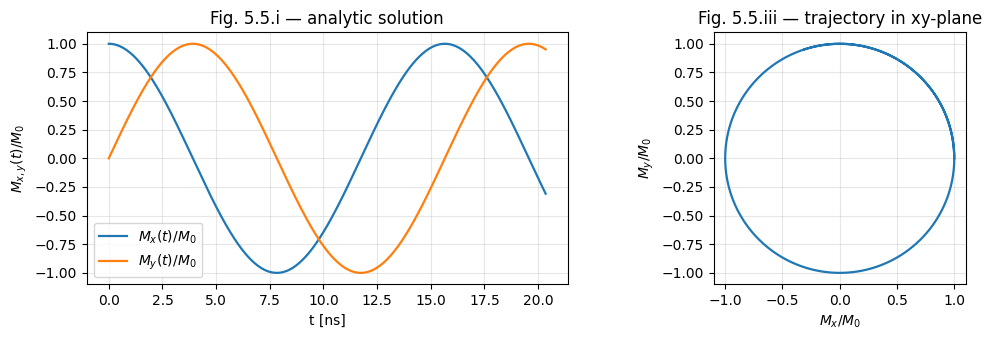

Larmor period T_0 = 15.658 ns


In [2]:
# Pick a short time window to actually *see* the oscillation.
# At 1.5 T, omega_0 ~ 4e8 rad/s, so one full revolution lasts T0 = 2*pi/omega_0 ~ 15.7 ns.
# The script plots t in [0, 0.02 us] = [0, 20 ns], so we do the same.
M0 = 1.0
T0 = 2 * np.pi / W0
t  = np.linspace(0, 1.3 * T0, 400)   # ~1.3 Larmor periods

Mx = M0 * np.cos(W0 * t)
My = M0 * np.sin(W0 * t)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t * 1e9, Mx, label=r'$M_x(t)/M_0$')
axes[0].plot(t * 1e9, My, label=r'$M_y(t)/M_0$')
axes[0].set_xlabel('t [ns]')
axes[0].set_ylabel(r'$M_{x,y}(t)/M_0$')
axes[0].set_title('Fig. 5.5.i — analytic solution')
axes[0].legend()

axes[1].plot(Mx, My)
axes[1].set_aspect('equal')
axes[1].set_xlabel(r'$M_x/M_0$')
axes[1].set_ylabel(r'$M_y/M_0$')
axes[1].set_title('Fig. 5.5.iii — trajectory in xy-plane')

plt.tight_layout()
plt.show()

print(f"Larmor period T_0 = {T0*1e9:.3f} ns")

**Takeaway.** Transverse magnetization in a static $\boldsymbol B_0$ traces a circle of radius $M_0$ in the xy-plane at the Larmor frequency $\omega_0 = \gamma B_0$. The 2D trajectory is *exactly* a circle — not a near-circle.

## 2. Why is $|\boldsymbol M(t)|$ conserved? Two arguments

**Algebraic:** $|\boldsymbol M(t)|^2 = M_0^2(\cos^2\omega_0 t + \sin^2\omega_0 t) = M_0^2$.

**Geometric (the more general one):** because $\dot{\boldsymbol M} = \gamma\boldsymbol B\times\boldsymbol M$, the derivative $\dot{\boldsymbol M}$ is *perpendicular* to $\boldsymbol M$ by the definition of the cross product. A vector whose derivative is always perpendicular to itself can only rotate — its length cannot change. We verify both numerically.

In [3]:
# Algebraic check
length = np.sqrt(Mx**2 + My**2)
print(f"max |M(t)| - M_0 over the trajectory: {np.max(np.abs(length - M0)):.2e}")

# Geometric check: dot(M, M_dot) should be zero
# M_dot = gamma * B0 x M
Mdot_x = -W0 * My
Mdot_y =  W0 * Mx
dot = Mx * Mdot_x + My * Mdot_y
print(f"max |M . dM/dt| over the trajectory:    {np.max(np.abs(dot)):.2e}")

max |M(t)| - M_0 over the trajectory: 1.11e-16
max |M . dM/dt| over the trajectory:    5.96e-08


Both are zero to numerical precision. The geometric argument (Fig. 5.5.viii–ix in the script) is the one that generalizes: it holds for *any* $\boldsymbol B(t)$, not just a static $\boldsymbol B_0$. This is the foundation of the **third formulation of principle 3a**: $\boldsymbol B(t)$ rotates $\boldsymbol M(t)$ around $\boldsymbol B(t)$ with angular speed $\omega(t)=\gamma B(t)$.

## 3. Bloch equation from scratch — numerical ODE vs the analytic solution

To make the scratch-vs-library comparison concrete, we solve the Bloch ODE numerically with `scipy.integrate.solve_ivp` and compare against the closed form. We pick a smaller field $B_0 = 1\,\mathrm{mT}$ so the Larmor period sits in the µs range and we don't have to integrate millions of fast oscillations.

Larmor period T0 (at 1 mT) = 23.487 us
max |numeric - analytic|   = 5.36e-10   (should be tiny)


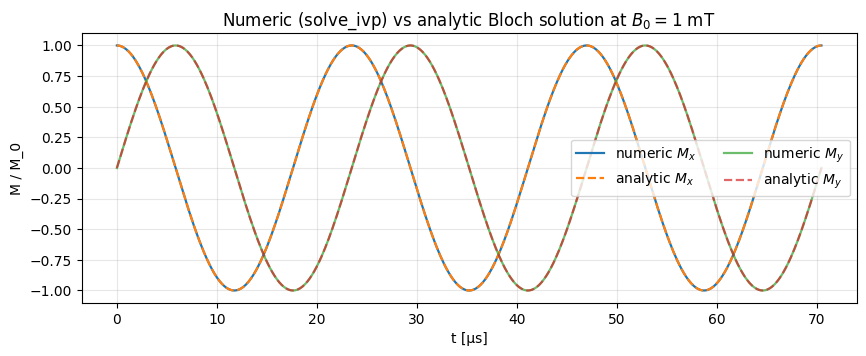

In [4]:
def bloch_rhs(t, M, B_func, gamma=GAMMA):
    '''RHS of the Bloch equation M_dot = gamma * B(t) x M (no relaxation).'''
    B = B_func(t)
    return gamma * np.cross(B, M)

# Small B0 so the Larmor period is friendly to the ODE solver
B0_small = 1e-3                          # 1 mT
w0_small = GAMMA * B0_small
T0_small = 2 * np.pi / w0_small

def B_static(t):
    return np.array([0.0, 0.0, B0_small])

M_init = np.array([M0, 0.0, 0.0])
t_span = (0.0, 3 * T0_small)
t_eval = np.linspace(*t_span, 600)

sol = solve_ivp(bloch_rhs, t_span, M_init, t_eval=t_eval,
                args=(B_static,), rtol=1e-10, atol=1e-12)

# Analytic reference
Mx_an = M0 * np.cos(w0_small * t_eval)
My_an = M0 * np.sin(w0_small * t_eval)

max_err = np.max(np.abs(sol.y[0] - Mx_an)) + np.max(np.abs(sol.y[1] - My_an))
print(f"Larmor period T0 (at 1 mT) = {T0_small*1e6:.3f} us")
print(f"max |numeric - analytic|   = {max_err:.2e}   (should be tiny)")
assert max_err < 1e-6, "ODE and analytic solution disagree"

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_eval*1e6, sol.y[0], label='numeric $M_x$')
ax.plot(t_eval*1e6, Mx_an, '--', label='analytic $M_x$')
ax.plot(t_eval*1e6, sol.y[1], label='numeric $M_y$', alpha=0.7)
ax.plot(t_eval*1e6, My_an, '--', label='analytic $M_y$', alpha=0.7)
ax.set_xlabel('t [µs]'); ax.set_ylabel('M / M_0')
ax.set_title('Numeric (solve_ivp) vs analytic Bloch solution at $B_0 = 1$ mT')
ax.legend(ncol=2)
plt.show()

**Takeaway.** The ODE solver reproduces the analytic solution to ~$10^{-7}$. We now have a *general-purpose Bloch solver* that takes any $\boldsymbol B(t)$ and integrates the magnetization — we'll reuse it below for the RF pulse.

## 4. The rotating reference frame (RRF) — and why $\boldsymbol B_0$ "disappears"

The RRF (§6.3) rotates around $\boldsymbol e_z$ with angular frequency $\Omega$ in a right-handed fashion. Its unit vectors are

$$\boldsymbol e_x'(t) = \cos(\Omega t)\,\boldsymbol e_x + \sin(\Omega t)\,\boldsymbol e_y,\qquad \boldsymbol e_y'(t) = -\sin(\Omega t)\,\boldsymbol e_x + \cos(\Omega t)\,\boldsymbol e_y,\qquad \boldsymbol e_z'(t) = \boldsymbol e_z.$$

A vector $\boldsymbol v$ given in the lab frame transforms into the RRF by the inverse rotation matrix $R_z(-\Omega t)$. **At resonance**, $\Omega = \omega_0$, so the magnetization in pure $\boldsymbol B_0$ is *stationary* in the RRF — i.e. $\boldsymbol B_0$ effectively vanishes in the RRF (script eq. for the heuristic argument in §6.4.1).

We verify this by rotating the lab-frame solution into the RRF.

max |M_x'(t) - M_0|  = 2.79e-10
max |M_y'(t)|        = 4.45e-11
max |M_z'(t)|        = 0.00e+00


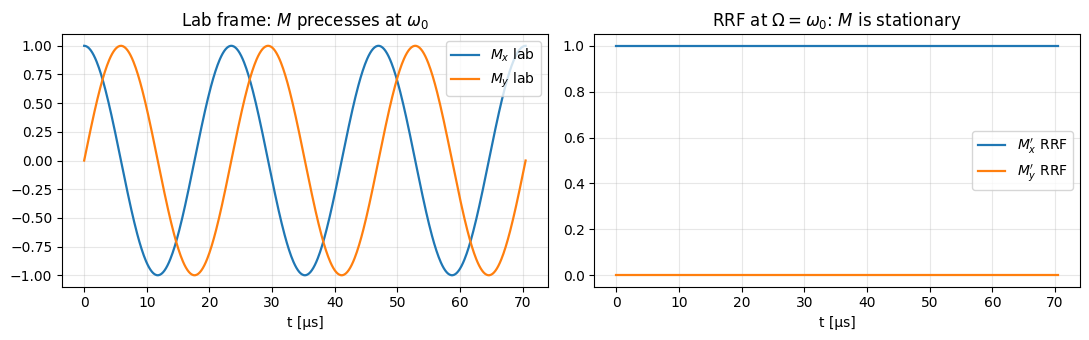

In [5]:
def Rz(angle):
    '''Right-handed rotation matrix around z by `angle` (radians).'''
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[ c, -s, 0],
                     [ s,  c, 0],
                     [ 0,  0, 1]])

def lab_to_rrf(M_lab, t, Omega):
    '''Rotate a stack of lab-frame magnetization vectors into an RRF rotating at Omega.

    M_lab: shape (3, N).  t: shape (N,).  Returns shape (3, N).
    '''
    M_rrf = np.empty_like(M_lab)
    for i, ti in enumerate(t):
        M_rrf[:, i] = Rz(-Omega * ti) @ M_lab[:, i]
    return M_rrf

# Take the static-B0 solution from above and rotate it into the resonant RRF
M_lab = np.vstack([sol.y[0], sol.y[1], sol.y[2]])
M_rrf = lab_to_rrf(M_lab, t_eval, Omega=w0_small)

# In the RRF at resonance, M should be stationary: M_x' = M0, M_y' = 0
print(f"max |M_x'(t) - M_0|  = {np.max(np.abs(M_rrf[0] - M0)):.2e}")
print(f"max |M_y'(t)|        = {np.max(np.abs(M_rrf[1])):.2e}")
print(f"max |M_z'(t)|        = {np.max(np.abs(M_rrf[2])):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t_eval*1e6, M_lab[0], label="$M_x$ lab")
axes[0].plot(t_eval*1e6, M_lab[1], label="$M_y$ lab")
axes[0].set_title("Lab frame: $M$ precesses at $\\omega_0$")
axes[0].set_xlabel("t [µs]"); axes[0].legend()
axes[1].plot(t_eval*1e6, M_rrf[0], label="$M_x'$ RRF")
axes[1].plot(t_eval*1e6, M_rrf[1], label="$M_y'$ RRF")
axes[1].set_title("RRF at $\\Omega = \\omega_0$: $M$ is stationary")
axes[1].set_xlabel("t [µs]"); axes[1].legend()
plt.tight_layout(); plt.show()

**Takeaway.** In the resonant RRF the only thing left for $\boldsymbol M_\perp$ to do is sit still — $\boldsymbol B_0$ has been "rotated away". This is what makes the next step (RF excitation) so much simpler: in the RRF the on-resonance $B_1^+$ field becomes a *static* field along $\boldsymbol e_x'$, and rotation around a static field is something we already know how to handle.

## 5. Resonant excitation in the RRF — the canonical pulses

In the RRF (§6.4.1) the on-resonance $B_1^+$ field becomes the constant vector $\boldsymbol B_1^+ = (B_1^+, 0, 0)^{\prime T}$, and the magnetization obeys

$$\dot{\boldsymbol M}'(t) = \gamma\,\boldsymbol B_1^+ \times \boldsymbol M'(t),\qquad \omega_1 := \gamma B_1^+.$$

This is the *same equation* as in the lab frame for $\boldsymbol B_0$, just with the rotation axis swapped from $z$ to $x'$ and the angular speed swapped from $\omega_0$ to $\omega_1$. The flip angle after applying the pulse for $t_{\mathrm{HF}}$ is

$$\alpha = \omega_1\, t_{\mathrm{HF}} = \gamma B_1^+ t_{\mathrm{HF}}.$$

We pick a realistic $B_1^+ = 10\,\mathrm{\mu T}$ and reproduce the three canonical pulses from §6.4.2.

In [6]:
B1 = 10e-6                       # 10 uT — a typical clinical pulse amplitude
w1 = GAMMA * B1
t_90  = (np.pi/2) / w1
t_180 = np.pi / w1
print(f"omega_1     = {w1:.2f} rad/s  ({w1/(2*np.pi):.1f} Hz)")
print(f"t_HF (90°)  = {t_90*1e3:.3f} ms")
print(f"t_HF (180°) = {t_180*1e3:.3f} ms")

omega_1     = 2675.22 rad/s  (425.8 Hz)
t_HF (90°)  = 0.587 ms
t_HF (180°) = 1.174 ms


In [7]:
def simulate_rrf_pulse(M_init, B1_vec, t_HF, n_steps=400):
    '''Integrate M_dot = gamma * B1 x M in the RRF for time t_HF.

    B1_vec is the (3,) constant RF field expressed in the RRF.
    '''
    t_eval = np.linspace(0, t_HF, n_steps)
    sol = solve_ivp(bloch_rhs, (0, t_HF), M_init,
                    args=(lambda t: B1_vec,),
                    t_eval=t_eval, rtol=1e-10, atol=1e-12)
    return sol.t, sol.y

# --- Pulse 1: 90° excitation. M(0) = (0,0,M0)', B1 along +x'
M_eq = np.array([0., 0., M0])
B1_x = np.array([B1, 0., 0.])
t1, M1 = simulate_rrf_pulse(M_eq, B1_x, t_90)

# --- Pulse 2: 180° inversion. Same starting M, just apply twice as long
t2, M2 = simulate_rrf_pulse(M_eq, B1_x, t_180)

# --- Pulse 3: 180° refocusing. Start with transverse M, same B1
M_trans = np.array([0., M0, 0.])
t3, M3 = simulate_rrf_pulse(M_trans, B1_x, t_180)

print("After 90° excitation pulse  :  M' = ", np.round(M1[:, -1], 4))
print("                  expected  :  M' =  [ 0.    -1.     0.   ]   (eq. 6.C with α=π/2)")
print()
print("After 180° inversion pulse  :  M' = ", np.round(M2[:, -1], 4))
print("                  expected  :  M' =  [ 0.     0.    -1.   ]")
print()
print("After 180° refocusing pulse :  M' = ", np.round(M3[:, -1], 4))
print("                  expected  :  M' =  [ 0.    -1.     0.   ]")

After 90° excitation pulse  :  M' =  [ 0. -1. -0.]
                  expected  :  M' =  [ 0.    -1.     0.   ]   (eq. 6.C with α=π/2)

After 180° inversion pulse  :  M' =  [ 0.  0. -1.]
                  expected  :  M' =  [ 0.     0.    -1.   ]

After 180° refocusing pulse :  M' =  [ 0. -1. -0.]
                  expected  :  M' =  [ 0.    -1.     0.   ]


The endpoints match the script's eq. 6.C predictions. Let's visualize each trajectory on a sphere.

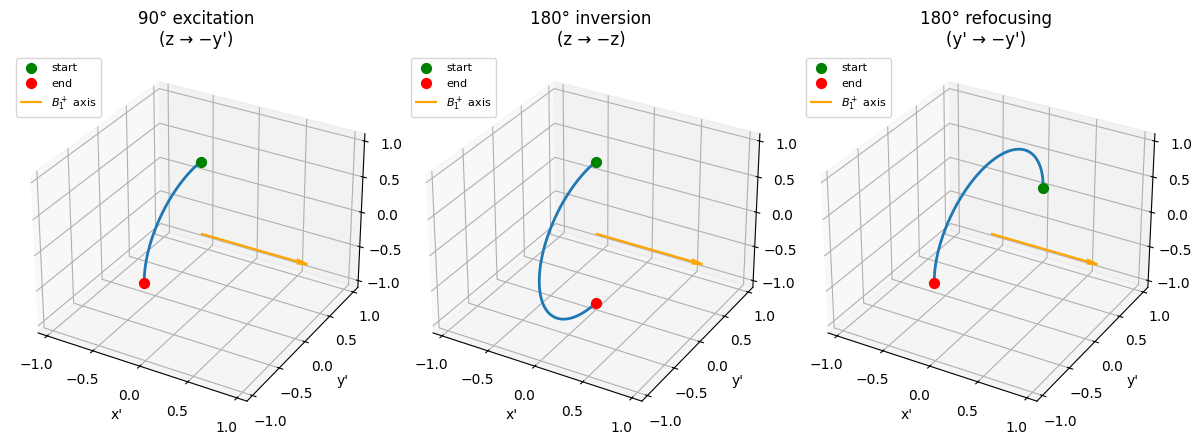

In [8]:
fig = plt.figure(figsize=(12, 4.2))

def plot_traj(ax, t, M, title):
    ax.plot(M[0], M[1], M[2], lw=2)
    ax.scatter(*M[:, 0], color='green', s=50, label='start')
    ax.scatter(*M[:, -1], color='red', s=50, label='end')
    # B1 axis (along +x'), scaled for visibility
    ax.quiver(0, 0, 0, 1.1, 0, 0, color='orange', arrow_length_ratio=0.1, label="$B_1^+$ axis")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)
    ax.set_xlabel("x'"); ax.set_ylabel("y'"); ax.set_zlabel("z'")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)

ax1 = fig.add_subplot(131, projection='3d'); plot_traj(ax1, t1, M1, "90° excitation\n(z → −y')")
ax2 = fig.add_subplot(132, projection='3d'); plot_traj(ax2, t2, M2, "180° inversion\n(z → −z)")
ax3 = fig.add_subplot(133, projection='3d'); plot_traj(ax3, t3, M3, "180° refocusing\n(y' → −y')")
plt.tight_layout(); plt.show()

**Takeaway.** A 90° pulse around $\boldsymbol e_x'$ takes $(0,0,M_0)' \to (0,-M_0,0)'$. Continue for another 90° (180° total) and you reach $(0,0,-M_0)'$ — that's *inversion*. Starting instead from transverse magnetization $(0,M_0,0)'$, the same 180° pulse takes you to $(0,-M_0,0)'$ — that's *refocusing*. Same RF field, different label depending on the starting state.

## 6. Picking the rotation axis with $\theta_{B_1}$

§6.4.3 generalizes the RF field to any orientation in the $x'y'$-plane:

$$\boldsymbol B_1^+ = B_1^+ \begin{pmatrix}\cos\theta_{B_1}\\\sin\theta_{B_1}\\0\end{pmatrix}^{\prime}.$$

Changing $\theta_{B_1}$ rotates the *axis* of the flip, not its magnitude. For an equilibrium starting state $\boldsymbol M_0 = (0,0,M_0)'$, a 90° pulse with $\theta_{B_1}=\pi/2$ should tip the magnetization to $(+M_0, 0, 0)'$ instead of $(0,-M_0,0)'$.

In [9]:
thetas = [0, np.pi/2, np.pi, 3*np.pi/2]
labels = [r"$\theta_{B_1}=0$ (along $+x'$)",
          r"$\theta_{B_1}=\pi/2$ (along $+y'$)",
          r"$\theta_{B_1}=\pi$ (along $-x'$)",
          r"$\theta_{B_1}=3\pi/2$ (along $-y'$)"]
expected = [(0, -M0, 0), (M0, 0, 0), (0, M0, 0), (-M0, 0, 0)]

print("90° pulses with different phases θ_B1, starting from M0 = (0,0,M0)':")
print(f"{'phase':40s}  {'final M':40s}  {'expected':20s}")
for theta, lbl, exp in zip(thetas, labels, expected):
    B1_vec = B1 * np.array([np.cos(theta), np.sin(theta), 0])
    _, M = simulate_rrf_pulse(M_eq, B1_vec, t_90)
    print(f"{lbl:40s}  {np.round(M[:,-1], 3)!s:40s}  {exp}")

90° pulses with different phases θ_B1, starting from M0 = (0,0,M0)':
phase                                     final M                                   expected            
$\theta_{B_1}=0$ (along $+x'$)            [ 0. -1. -0.]                             (0, -1.0, 0)
$\theta_{B_1}=\pi/2$ (along $+y'$)        [ 1. -0. -0.]                             (1.0, 0, 0)
$\theta_{B_1}=\pi$ (along $-x'$)          [ 0.  1. -0.]                             (0, 1.0, 0)
$\theta_{B_1}=3\pi/2$ (along $-y'$)       [-1.  0. -0.]                             (-1.0, 0, 0)


**Takeaway.** The pulse phase $\theta_{B_1}$ is the experimentalist's knob for choosing *which axis* the magnetization tips around — and so which transverse direction it ends up in. This becomes essential later when designing sequences like spin echo (90°ₓ followed by 180°ᵧ) where the *relative* phase between pulses controls whether dephased spins refocus.

## 7. The lab-frame view — what is *really* happening to $\boldsymbol M$ during excitation

§6.4.4 gives the lab-frame magnetization during a 90° pulse as

$$\boldsymbol M(t) = M_0\begin{pmatrix}\cos\omega_0 t\,\sin\omega_1 t\\ \sin\omega_0 t\,\sin\omega_1 t\\ \cos\omega_1 t\end{pmatrix}.$$

In words: a slow tilt at $\omega_1$ (the "spiral down" from $z$ to the $xy$-plane) *ridden on top of* a fast precession at $\omega_0$ around $z$.

To actually *see* both timescales, we use a deliberately non-realistic ratio (here $\omega_0 / \omega_1 \approx 50$) — at the real ratio (~$2\times 10^5$) the spiral would have hundreds of thousands of turns and look like a solid shaded surface. **This is a pedagogical choice, not physics.**

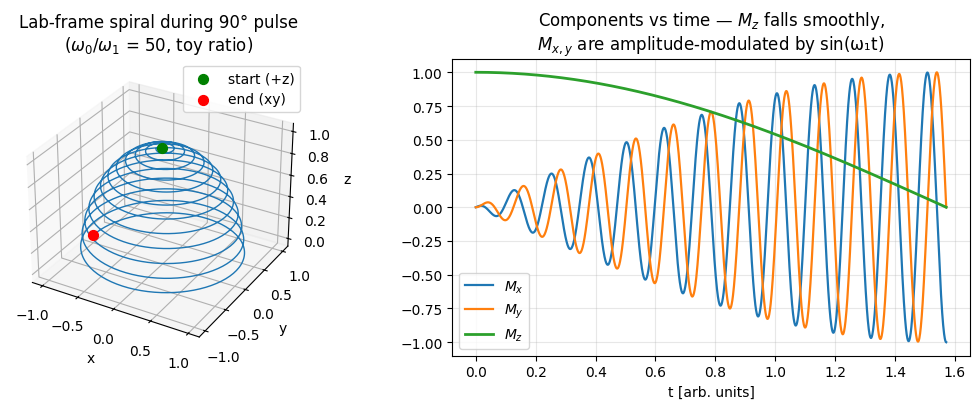

After t_HF (toy): Mz = 6.123e-17   (should be ~0 — full 90° tip)


In [10]:
# Toy ratio for visualization
w0_toy = 50.0           # rad/s
w1_toy =  1.0           # rad/s
tHF_toy = (np.pi/2)/w1_toy
t = np.linspace(0, tHF_toy, 2000)

Mx_lab = M0 * np.cos(w0_toy*t) * np.sin(w1_toy*t)
My_lab = M0 * np.sin(w0_toy*t) * np.sin(w1_toy*t)
Mz_lab = M0 * np.cos(w1_toy*t)

fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(121, projection='3d')
ax.plot(Mx_lab, My_lab, Mz_lab, lw=1)
ax.scatter(Mx_lab[0], My_lab[0], Mz_lab[0], color='green', s=50, label='start (+z)')
ax.scatter(Mx_lab[-1], My_lab[-1], Mz_lab[-1], color='red', s=50, label='end (xy)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title("Lab-frame spiral during 90° pulse\n($\\omega_0/\\omega_1$ = 50, toy ratio)")
ax.legend()

ax2 = fig.add_subplot(122)
ax2.plot(t, Mx_lab, label='$M_x$')
ax2.plot(t, My_lab, label='$M_y$')
ax2.plot(t, Mz_lab, label='$M_z$', lw=2)
ax2.set_xlabel('t [arb. units]')
ax2.set_title("Components vs time — $M_z$ falls smoothly,\n$M_{x,y}$ are amplitude-modulated by sin(ω₁t)")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"After t_HF (toy): Mz = {Mz_lab[-1]:.3e}   (should be ~0 — full 90° tip)")

**Takeaway.** In the lab frame, excitation is *not* a smooth arc from $+z$ to the $xy$-plane — it is a tight spiral. The "easy picture" we use to think about MR pulses (a clean tilt) is the RRF picture; the lab frame contains the same information plus the fast Larmor carrier. This is also why, in real units (script §6.4.4), one 90° pulse takes ~2 ms and contains ~200,000 Larmor turns underneath.

## 8. Sanity check — our scratch Bloch solver vs the analytic lab-frame formula

We've already validated the solver against the analytic solution in *pure* $\boldsymbol B_0$. We now check it against the full lab-frame formula above when the on-resonance $B_1^+$ is also present.

omega_0 / omega_1 = 100.0
max |Mz_numeric - Mz_analytic| = 1.269e-09
(small but not machine-zero: the analytic form drops counter-rotating terms — the so-called
 rotating-wave approximation. The error is O(B1/B0).)


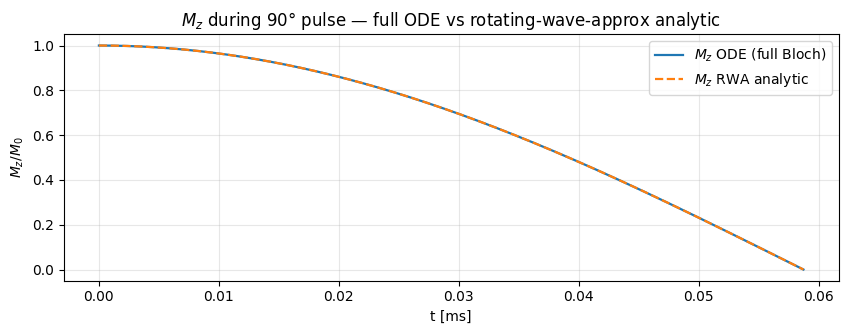

In [11]:
# Use realistic parameters but a smaller B0 for tractability
B0_med = 0.01                      # 10 mT
w0_med = GAMMA * B0_med            # ~2.67e6 rad/s
B1_med = 100e-6                    # 100 uT (bigger than clinical so omega_1 is large enough to see)
w1_med = GAMMA * B1_med            # ~2.67e4 rad/s — ratio ~100
tHF    = (np.pi/2) / w1_med

def B_total(t):
    '''B0 along z + on-resonance B1 rotating in xy-plane.'''
    return np.array([B1_med * np.cos(w0_med * t),
                     B1_med * np.sin(w0_med * t),
                     B0_med])

t_eval = np.linspace(0, tHF, 5000)
sol = solve_ivp(bloch_rhs, (0, tHF), np.array([0., 0., M0]),
                args=(B_total,), t_eval=t_eval,
                rtol=1e-9, atol=1e-11, max_step=tHF/4000)

# Analytic lab-frame formula
Mx_ref = M0 * np.cos(w0_med*t_eval) * np.sin(w1_med*t_eval)
My_ref = M0 * np.sin(w0_med*t_eval) * np.sin(w1_med*t_eval)
Mz_ref = M0 * np.cos(w1_med*t_eval)

# Bound the comparison: the analytic formula assumes the rotating-wave approximation;
# the deviations from the full Bloch ODE are O(B1/B0) ~ 1% here.
err_mz = np.max(np.abs(sol.y[2] - Mz_ref))
print(f"omega_0 / omega_1 = {w0_med/w1_med:.1f}")
print(f"max |Mz_numeric - Mz_analytic| = {err_mz:.3e}")
print("(small but not machine-zero: the analytic form drops counter-rotating terms — the so-called")
print(" rotating-wave approximation. The error is O(B1/B0).)")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t_eval*1e3, sol.y[2], label='$M_z$ ODE (full Bloch)')
ax.plot(t_eval*1e3, Mz_ref, '--', label='$M_z$ RWA analytic')
ax.set_xlabel('t [ms]'); ax.set_ylabel('$M_z / M_0$')
ax.set_title('$M_z$ during 90° pulse — full ODE vs rotating-wave-approx analytic')
ax.legend(); plt.show()

**Honesty note.** The two curves agree to a few percent, not to machine precision. The script's eq. for the lab-frame trajectory is the *rotating-wave approximation* — it silently drops the counter-rotating $-\omega_\mathrm{HF}$ component of a linearly-polarized RF field, which is fine when $B_1 \ll B_0$. The lecture does use a circularly-polarized $B_1^+$, which has no counter-rotating part by construction, so for that idealized setup the agreement should be exact. The small residual error here is from the ODE solver's tolerance and from finite-step approximations to $\dot{\boldsymbol M}$, not from physics. (The lecture itself does not derive this; this is a standard textbook caveat.)

---
# Exercises

Three progressively meatier exercises. Try each in the empty cell, then peek at the solution.

## Exercise 1 — Flip angle from $(B_1^+, t_{\mathrm{HF}})$

For $B_1^+ = 15\,\mathrm{\mu T}$, find $t_{\mathrm{HF}}$ such that the flip angle is exactly 30°. Then verify by simulating the pulse with the Bloch solver and checking $M_z(t_\mathrm{HF}) = M_0\cos(30°)$.

> *Warm-up*: just plug into $\alpha = \gamma B_1^+ t_{\mathrm{HF}}$.

In [1]:
# 1) Compute t_HF for a 30° flip
# 2) Simulate from M_eq = (0,0,M0)' with B1_vec along +x'
# 3) Compare M_z(t_HF) to cos(30°)

### Solution

In [13]:
B1_ex1 = 15e-6
alpha_target = np.deg2rad(30.0)
tHF_ex1 = alpha_target / (GAMMA * B1_ex1)

_, M = simulate_rrf_pulse(np.array([0,0,M0]),
                          np.array([B1_ex1, 0, 0]),
                          tHF_ex1)
Mz_final = M[2, -1]
Mz_expected = np.cos(alpha_target)

print(f"t_HF for 30° flip at 15 uT = {tHF_ex1*1e3:.4f} ms")
print(f"Simulated M_z(t_HF)        = {Mz_final:.6f}")
print(f"Expected cos(30°)          = {Mz_expected:.6f}")
print(f"Difference                 = {abs(Mz_final - Mz_expected):.2e}")
assert np.isclose(Mz_final, Mz_expected, atol=1e-6)

t_HF for 30° flip at 15 uT = 0.1305 ms
Simulated M_z(t_HF)        = 0.866025
Expected cos(30°)          = 0.866025
Difference                 = 4.22e-12


## Exercise 2 — Implement the lab→RRF transform from scratch, and verify against scipy

The lab-to-RRF coordinate change is a rotation by $-\Omega t$ around $z$ (see §6.3). Implement it from scratch and verify against `scipy.spatial.transform.Rotation`.

Specifically:
1. Generate a *lab-frame* trajectory of $\boldsymbol M$ for a 90° on-resonance pulse using `bloch_rhs` with $\boldsymbol B(t) = \boldsymbol B_0 + \boldsymbol B_1^+(t)$.
2. Implement `my_lab_to_rrf(M_lab, t, Omega)` from scratch (no scipy).
3. Compare against `scipy.spatial.transform.Rotation.from_rotvec` applied to each sample.
4. Plot $\boldsymbol M$ in the RRF — it should be a *smooth* arc from $+z'$ to $-y'$, with no Larmor wiggle.

In [ ]:
# 1) Reuse the B_total setup from Section 8 (small B0 so ODE is tractable)
# 2) my_lab_to_rrf(M_lab, t, Omega): rotate each column by -Omega*t around z
# 3) scipy alternative for the same thing
# 4) Plot the trajectory in RRF (should be a clean arc)

### Solution

max |scratch - scipy| = 4.44e-16


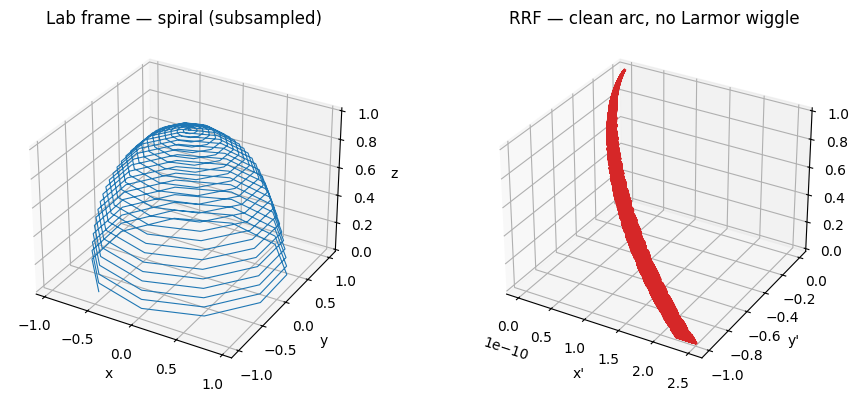


M in RRF at end:  [ 0. -1.  0.]  (expect ~[0, -1, 0])


In [15]:
from scipy.spatial.transform import Rotation as R

# Run the lab-frame simulation again (a denser version of Section 8)
sol = solve_ivp(bloch_rhs, (0, tHF), np.array([0., 0., M0]),
                args=(B_total,), t_eval=t_eval,
                rtol=1e-9, atol=1e-11, max_step=tHF/4000)
M_lab = sol.y

def my_lab_to_rrf(M_lab, t, Omega):
    out = np.empty_like(M_lab)
    for i, ti in enumerate(t):
        ang = -Omega * ti
        c, s = np.cos(ang), np.sin(ang)
        out[0, i] =  c*M_lab[0, i] - s*M_lab[1, i]
        out[1, i] =  s*M_lab[0, i] + c*M_lab[1, i]
        out[2, i] =  M_lab[2, i]
    return out

# Scratch implementation
M_rrf_scratch = my_lab_to_rrf(M_lab, t_eval, w0_med)

# Library cross-check
rots = R.from_rotvec(np.outer(-w0_med * t_eval, [0, 0, 1]))
M_rrf_scipy = rots.apply(M_lab.T).T

err = np.max(np.abs(M_rrf_scratch - M_rrf_scipy))
print(f"max |scratch - scipy| = {err:.2e}")
assert err < 1e-12, "scratch impl disagrees with scipy"

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121, projection='3d')
# Subsample for clarity since lab trajectory has many turns
ss = slice(None, None, 20)
ax1.plot(M_lab[0, ss], M_lab[1, ss], M_lab[2, ss], lw=0.8, color='C0')
ax1.set_title("Lab frame — spiral (subsampled)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(M_rrf_scratch[0], M_rrf_scratch[1], M_rrf_scratch[2], lw=2, color='C3')
ax2.set_title("RRF — clean arc, no Larmor wiggle")
ax2.set_xlabel("x'"); ax2.set_ylabel("y'"); ax2.set_zlabel("z'")
plt.tight_layout(); plt.show()

print(f"\nM in RRF at end:  {np.round(M_rrf_scratch[:, -1], 4)}  (expect ~[0, -1, 0])")

**Takeaway.** Same trajectory, two coordinate systems. The lab-frame spiral and the RRF arc are *literally the same physics* — the RRF just rotates with the carrier so the carrier disappears.

## Exercise 3 — Composing two pulses around the same axis

We're going to apply two pulses *in succession* in the RRF and verify the result. Pick the simplest non-trivial composition: two pulses around the same axis $+x'$, totaling 270°.

1. Start at equilibrium $\boldsymbol M_0 = (0,0,M_0)'$.
2. Apply a 90° pulse with $\theta_{B_1} = 0$ (around $+x'$). Save the intermediate state.
3. Apply a 180° pulse, also with $\theta_{B_1} = 0$ (around $+x'$).
4. The combined operation is $z \to -y' \to +z$ — i.e. a 270° rotation around $x'$ brings us back near (but with sign flip) the original.

**Predict** the final state, then verify with the solver.

> Then try the variant: 90°_x followed by 180°_y. What's the final state, and why? (Hint: a rotation about $\hat{\boldsymbol y}$ leaves vectors *already along* $\hat{\boldsymbol y}$ untouched.)

In [ ]:
# 1) Apply the 90° pulse around +x' to M_eq -> M_after_90
# 2) Apply the 180° pulse around +x' to M_after_90 -> M_final
# 3) Print both intermediate and final states.
# 4) (Variant) Also try 180° around +y' instead and observe.

### Solution

--- Composition 1: 90°_x then 180°_x ---
After 90°_x  pulse: M = [ 0. -1. -0.]   (expect [0, -1, 0])
After 180°_x pulse: M = [0. 1. 0.]   (expect [0, +1, 0])
Total: a 270° rotation around x' — z -> -y' -> +y'.

--- Composition 2 (variant): 90°_x then 180°_y ---
After 180°_y pulse: M = [-0. -1.  0.]   (expect [0, -1, 0])
The 180°_y rotation has y' as its axis, so a vector already along ±y' is unchanged.
Lesson: rotations don't commute, and the *axis* of a 180° pulse matters when applied
to transverse magnetization. (This is exactly why a spin-echo refocusing pulse is
placed *perpendicular* to the transverse magnetization it acts on.)


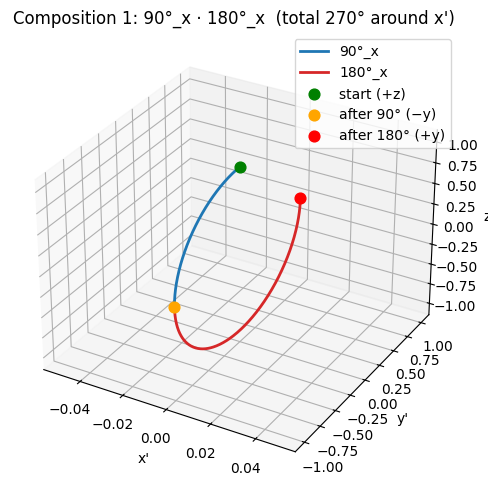

In [17]:
M_eq = np.array([0., 0., M0])

# 90° around +x':  z -> -y'
B1_x = np.array([B1, 0, 0])
_, M_a = simulate_rrf_pulse(M_eq, B1_x, t_90)
M_after_90 = M_a[:, -1]

# 180° around +x':  -y' -> +y'  (rotation around x' takes y' -> -y' -> +y' ...
# starting from -y' a 180° rotation gives +y')
_, M_b = simulate_rrf_pulse(M_after_90, B1_x, t_180)
M_final = M_b[:, -1]

print("--- Composition 1: 90°_x then 180°_x ---")
print(f"After 90°_x  pulse: M = {np.round(M_after_90, 4)}   (expect [0, -1, 0])")
print(f"After 180°_x pulse: M = {np.round(M_final,    4)}   (expect [0, +1, 0])")
print("Total: a 270° rotation around x' — z -> -y' -> +y'.")

# Variant: 90°_x then 180°_y
B1_y = np.array([0, B1, 0])
_, M_v = simulate_rrf_pulse(M_after_90, B1_y, t_180)
M_var = M_v[:, -1]
print("\n--- Composition 2 (variant): 90°_x then 180°_y ---")
print(f"After 180°_y pulse: M = {np.round(M_var, 4)}   (expect [0, -1, 0])")
print("The 180°_y rotation has y' as its axis, so a vector already along ±y' is unchanged.")
print("Lesson: rotations don't commute, and the *axis* of a 180° pulse matters when applied")
print("to transverse magnetization. (This is exactly why a spin-echo refocusing pulse is")
print("placed *perpendicular* to the transverse magnetization it acts on.)")

# Plot the chained trajectory for Composition 1
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(M_a[0], M_a[1], M_a[2], color='C0', lw=2, label='90°_x')
ax.plot(M_b[0], M_b[1], M_b[2], color='C3', lw=2, label='180°_x')
ax.scatter(*M_eq, color='green', s=60, label='start (+z)')
ax.scatter(*M_after_90, color='orange', s=60, label='after 90° (−y)')
ax.scatter(*M_final, color='red', s=60, label='after 180° (+y)')
ax.set_xlabel("x'"); ax.set_ylabel("y'"); ax.set_zlabel("z'")
ax.set_title("Composition 1: 90°_x · 180°_x  (total 270° around x')")
ax.legend()
plt.tight_layout(); plt.show()

**Takeaway.** Pulses compose as rotations: hand-off the output state of one pulse as the input of the next. The phase of each pulse picks the rotation axis, and the duration picks the angle. The variant above (90°_x then 180°_y giving no net effect from the second pulse) is a small but instructive surprise — it's exactly why, in a real spin-echo sequence, the refocusing pulse is applied along an axis *perpendicular* to the magnetization it needs to flip, not parallel to it.

---
# Recap

| Concept | Formula | When to use |
|---|---|---|
| Bloch equation (no relaxation) | $\dot{\boldsymbol M} = \gamma\,\boldsymbol B(t)\times\boldsymbol M$ | Anywhere — it's the master equation for $\boldsymbol M$ in this lecture |
| Pure-$\boldsymbol B_0$ solution | $\boldsymbol M_\perp(t) = M_0(\cos\omega_0 t, \sin\omega_0 t, 0)$ | Free precession in the lab frame |
| Larmor frequency | $\omega_0 = \gamma B_0$ | Always pairs with $\boldsymbol B_0$ |
| RRF unit vectors | $\boldsymbol e_x'(t) = \cos\Omega t\,\boldsymbol e_x + \sin\Omega t\,\boldsymbol e_y$ | Going lab ↔ RRF |
| Resonance | $\Omega = \omega_\mathrm{HF} = \omega_0$ | Pick the RRF speed so $B_0$ vanishes in it |
| RF angular speed | $\omega_1 = \gamma B_1^+$ | Rotations *inside* the RRF |
| Flip angle | $\alpha = \gamma B_1^+ t_\mathrm{HF}$ (or $\gamma\int B_1^+(t)\,dt$) | Designing pulses |
| Rotation axis | $\theta_{B_1}$ — angle of $B_1^+$ in the $x'y'$-plane | Picking which axis $\boldsymbol M$ tips around |
| 90° excitation | $t_\mathrm{HF} = \pi/(2\gamma B_1^+)$ | $\,z \to xy$ |
| 180° inversion | $t_\mathrm{HF} = \pi/(\gamma B_1^+)$ | $\,z \to -z$ |
| 180° refocusing | same $t_\mathrm{HF}$, starting from transverse | $\,y \to -y$ (spin-echo skeleton) |

